# ch283 — Overfitting

*(Mechanically explains the train/test gap from ch282; connects to bias-variance from ch276)*

## 1. What Overfitting Is

Overfitting occurs when a model learns the noise in the training data rather than the underlying signal. The model's variance exceeds the benefit of reduced bias.

Three equivalent framings:
1. **Statistical**: high variance estimator (ch276)
2. **Information-theoretic**: model complexity exceeds dataset information content
3. **Functional**: model memorizes training points instead of generalizing

---

## 2. Overfitting by Demonstration

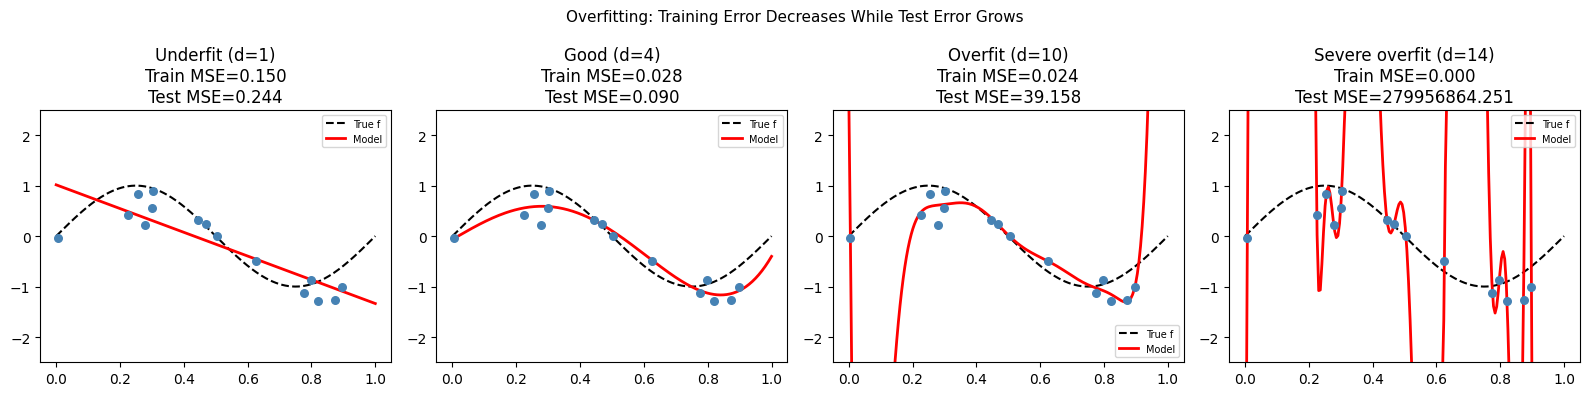

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

def true_f(x): return np.sin(2 * np.pi * x)

x_train = rng.uniform(0, 1, 15)
y_train = true_f(x_train) + rng.normal(0, 0.3, 15)
x_test  = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, deg, label in zip(axes, [1, 4, 10, 14],
    ['Underfit (d=1)', 'Good (d=4)', 'Overfit (d=10)', 'Severe overfit (d=14)']):
    coeffs = np.polyfit(x_train, y_train, deg)
    y_pred_train = np.polyval(coeffs, x_train)
    y_pred_test  = np.polyval(coeffs, x_test)

    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse  = np.mean((true_f(x_test) - y_pred_test)**2)

    ax.scatter(x_train, y_train, color='steelblue', s=30, zorder=5)
    ax.plot(x_test, true_f(x_test), 'k--', lw=1.5, label='True f')
    ax.plot(x_test, np.clip(y_pred_test, -3, 3), 'r-', lw=2, label='Model')
    ax.set_title(f'{label}\nTrain MSE={train_mse:.3f}\nTest MSE={test_mse:.3f}')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=7)

plt.suptitle('Overfitting: Training Error Decreases While Test Error Grows', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Regularization

Regularization constrains model complexity by adding a penalty to the loss function:

- **Ridge (L2)**: $\text{Loss} + \lambda \|\boldsymbol{\beta}\|_2^2$ — shrinks all coefficients toward zero
- **Lasso (L1)**: $\text{Loss} + \lambda \|\boldsymbol{\beta}\|_1$ — produces sparse solutions (some coefficients exactly zero)

$(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ → Ridge closed form: $(\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$

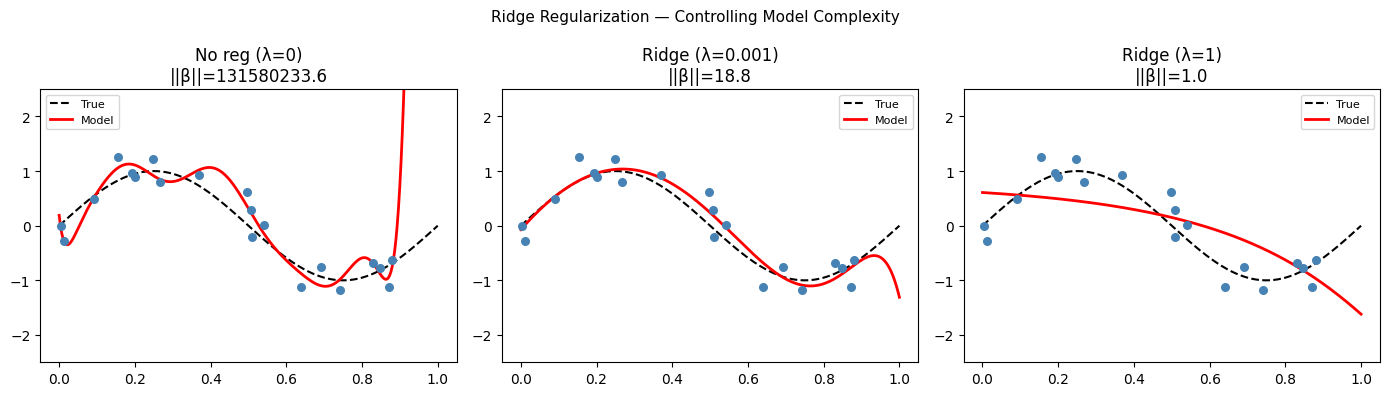

In [2]:
def ridge_regression(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """
    Ridge regression: minimizes ||Xβ - y||² + λ||β||²
    Closed form: β = (X^T X + λI)^{-1} X^T y
    X should NOT include intercept column (intercept not regularized).
    """
    n, p = X.shape
    # Add intercept
    X1 = np.column_stack([np.ones(n), X])
    # Build regularization matrix (don't regularize intercept)
    reg = lam * np.eye(p + 1)
    reg[0, 0] = 0.0  # no penalty on intercept
    return np.linalg.solve(X1.T @ X1 + reg, X1.T @ y)

# High-degree polynomial with and without ridge
n = 20
x_r = rng.uniform(0, 1, n)
y_r = np.sin(2*np.pi*x_r) + rng.normal(0, 0.3, n)

# Vandermonde design matrix (degree 14, no intercept — added in ridge_regression)
deg = 14
X_poly = np.column_stack([x_r**d for d in range(1, deg+1)])
x_grid = np.linspace(0, 1, 300)
X_grid = np.column_stack([x_grid**d for d in range(1, deg+1)])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, lam, title in zip(axes, [0, 1e-3, 1e0], ['No reg (λ=0)', 'Ridge (λ=0.001)', 'Ridge (λ=1)']):
    beta = ridge_regression(X_poly, y_r, lam)
    X_grid_int = np.column_stack([np.ones(300), X_grid])
    y_grid = X_grid_int @ beta

    ax.scatter(x_r, y_r, color='steelblue', s=30, zorder=5)
    ax.plot(x_grid, np.sin(2*np.pi*x_grid), 'k--', lw=1.5, label='True')
    ax.plot(x_grid, np.clip(y_grid, -3, 3), 'r-', lw=2, label='Model')
    coef_norm = np.linalg.norm(beta[1:])
    ax.set_title(f'{title}\n||β||={coef_norm:.1f}')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Ridge Regularization — Controlling Model Complexity', fontsize=11)
plt.tight_layout()
plt.show()

## 4. What Comes Next

The optimal $\lambda$ is a hyperparameter. **ch284 — Cross Validation** provides the procedure for selecting it empirically. In **ch296 — Optimization Methods**, regularization is reinterpreted as a Bayesian prior on model parameters — a unified view that generalizes beyond regression.